In [7]:
from __future__ import annotations
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [8]:
def strip_host(col: str) -> str:
    """Remove the machine prefix from PDH telemetry column names."""
    return re.sub(r"^\\\\[^\\]+\\", "", col).strip()


def load_pdh_csv(path: str | Path) -> pd.DataFrame:
    """Load a telemetry CSV, drop the timestamp column, and keep numeric features."""
    df = pd.read_csv(path, low_memory=False)
    df.columns = [strip_host(c) if i > 0 else "timestamp" for i, c in enumerate(df.columns)]
    df = df.drop(columns=["timestamp"], errors="ignore")

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    return df

In [9]:

def load_combined_dataset(data_dir: str | Path) -> tuple[pd.DataFrame, list[str]]:
    """Load the cleaned combined dataset and return numeric feature columns."""
    combined = pd.read_csv("data/cleaned_combined.csv", low_memory=False)

    feature_cols = [
        c for c in combined.columns
        if c not in ["timestamp", "os", "label", "source_file"]
]

    for c in feature_cols:
        combined[c] = pd.to_numeric(combined[c], errors="coerce")

    combined = combined.dropna(subset=feature_cols, how="all")
    if "source_file" not in combined.columns:
        combined["source_file"] = "cleaned_combined.csv"

    return combined, feature_cols

In [10]:
class SimpleAnomalyDetector:
    """Small anomaly detector built on StandardScaler + IsolationForest."""

    def __init__(self, contamination: float = 0.05, random_state: int = 42):
        self.contamination = contamination
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.model = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=random_state,
            n_jobs=-1,
        )
        self.feature_names: list[str] | None = None

    def fit(self, X, feature_names: list[str] | None = None):
        self.feature_names = feature_names
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled)

        scores = self.score(X)
        flags = self.predict(X)

        print("\nIsolationForest detector fitted")
        print(f"   Training samples : {len(X):,}")
        print(f"   Features         : {X.shape[1]}")
        print(f"   Contamination    : {self.contamination:.2%}")
        print(
            "   Score (p50/p95/p99/max): "
            f"{pd.Series(scores).quantile(0.50):.3f} / "
            f"{pd.Series(scores).quantile(0.95):.3f} / "
            f"{pd.Series(scores).quantile(0.99):.3f} / "
            f"{pd.Series(scores).max():.3f}"
        )
        print(f"   Flagged on train : {int(flags.sum())} ({100 * flags.mean():.1f}%)")
        return self

    def score(self, X):
        """Return anomaly scores where larger values mean more anomalous."""
        X_scaled = self.scaler.transform(X)
        return -self.model.decision_function(X_scaled)

    def predict(self, X):
        """Return binary labels: 1 = anomaly, 0 = normal."""
        X_scaled = self.scaler.transform(X)
        return (self.model.predict(X_scaled) == -1).astype(int)

    def score_dataframe(self, df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
        X = df[feature_cols].to_numpy()
        scores = self.score(X)
        flags = self.predict(X)
        results = df.copy()
        results["anomaly_score"] = scores.round(4)
        results["anomaly_flag"] = flags
        return results

    def plot(self, results: pd.DataFrame):
        """Simple diagnostics for the combined dataset."""
        scores = pd.Series(results["anomaly_score"], dtype=float)
        flags = results["anomaly_flag"].astype(bool)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        fig.suptitle("IsolationForest Anomaly Detection", fontsize=14)

        axes[0].hist(scores, bins=50, color="#2A9D8F", alpha=0.8)
        axes[0].set_title("Anomaly score distribution")
        axes[0].set_xlabel("Anomaly score")
        axes[0].set_ylabel("Count")

        axes[1].plot(scores, lw=0.7, color="#457B9D")
        axes[1].scatter(scores.index[flags], scores[flags], s=8, color="#E63946", label="Anomaly")
        axes[1].set_title("Scores across combined samples")
        axes[1].set_xlabel("Sample index")
        axes[1].set_ylabel("Anomaly score")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

In [11]:
DATA_DIR = "data"
CONTAMINATION = 0.05
NO_PLOT = False

Loading combined PDH-CSV data …
   29,146 samples  |  70 features  |  7 files

IsolationForest detector fitted
   Training samples : 29,146
   Features         : 70
   Contamination    : 5.00%
   Score (p50/p95/p99/max): -0.126 / 0.000 / 0.068 / 0.154
   Flagged on train : 1458 (5.0%)
                     timestamp  Processor_DPC Rate  Processor_% Idle Time  \
0      2019-04-01 23:12:31.353                  14              74.791667   
1      2019-04-01 23:12:46.353                   0              90.208333   
2      2019-04-01 23:13:01.353                   0              99.791667   
3      2019-04-01 23:13:16.353                   0              99.791667   
4      2019-04-01 23:13:31.353                   0              99.687500   
...                        ...                 ...                    ...   
29141  2019-04-04 01:06:05.445                   0              98.553336   
29142  2019-04-04 01:06:15.460                   0              97.682586   
29143  2019-04-04 01:

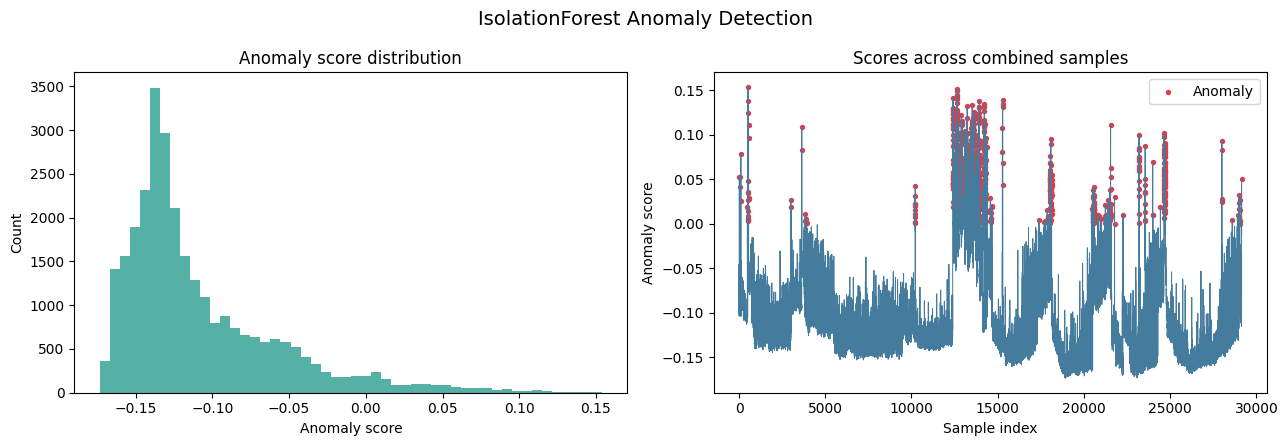

In [12]:
print("Loading combined PDH-CSV data …")
combined, feature_cols = load_combined_dataset(DATA_DIR)
print(f"   {len(combined):,} samples  |  {len(feature_cols)} features  |  {combined['source_file'].nunique()} files")

X = combined[feature_cols]

detector = SimpleAnomalyDetector(contamination=CONTAMINATION)
detector.fit(X, feature_names=feature_cols)

results = detector.score_dataframe(combined, feature_cols)
print(results)

anomaly_count = int(results["anomaly_flag"].sum())
print(f"\nAnomalies detected: {anomaly_count} / {len(results)} samples ({100 * anomaly_count / len(results):.1f}%)")
print(f"Results saved → {OUTPUT_PATH}")

print("\nTop 5 most anomalous samples:")
print(
    results.nlargest(5, "anomaly_score")[["source_file", "anomaly_score", "anomaly_flag"]]
    .to_string(index=False)
)

if not NO_PLOT:
    detector.plot(results)